**Importing the Libraries**

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Importing the Dataset**

In [102]:
dataset = pd.read_csv('Telco-Customer-Churn_Dataset.csv')
X = dataset.drop('Churn', axis=1)
y = dataset['Churn']


**Take Care of Missing Values**

In [103]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')
dataset['TotalCharges'] = dataset['TotalCharges'].fillna(dataset['TotalCharges'].median())
if 'customerID' in dataset.columns:
    dataset = dataset.drop('customerID', axis=1)

**One-Hot Encoding Categorical Data**

In [104]:
X = dataset.drop('Churn', axis=1)
categorical_cols = X.select_dtypes(include=['object']).columns

from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

X = ct.fit_transform(X)




In [105]:
print(X)

[[0.0000e+00 1.0000e+00 0.0000e+00 ... 1.0000e+00 2.9850e+01 2.9850e+01]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 3.4000e+01 5.6950e+01 1.8895e+03]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 2.0000e+00 5.3850e+01 1.0815e+02]
 ...
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 1.1000e+01 2.9600e+01 3.4645e+02]
 [1.0000e+00 1.0000e+00 0.0000e+00 ... 4.0000e+00 7.4400e+01 3.0660e+02]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 6.6000e+01 1.0565e+02 6.8445e+03]]


In [106]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)  # Yes=1, No=0

In [107]:
print(y)

[0 0 1 ... 0 1 0]


**Splitting Dataset into Training and Test Set**

In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [109]:
print(X_train)

[[0.00000e+00 0.00000e+00 1.00000e+00 ... 2.10000e+01 6.48500e+01
  1.33680e+03]
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 5.40000e+01 9.72000e+01
  5.12945e+03]
 [1.00000e+00 1.00000e+00 0.00000e+00 ... 1.00000e+00 2.34500e+01
  2.34500e+01]
 ...
 [1.00000e+00 1.00000e+00 1.00000e+00 ... 1.20000e+01 2.11500e+01
  3.06050e+02]
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 1.20000e+01 9.94500e+01
  1.20015e+03]
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 2.60000e+01 1.98000e+01
  4.57300e+02]]


In [110]:
print(X_test)

[[0.0000e+00 1.0000e+00 0.0000e+00 ... 1.0000e+00 2.4800e+01 2.4800e+01]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 4.1000e+01 2.5250e+01 9.9645e+02]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 5.2000e+01 1.9350e+01 1.0317e+03]
 ...
 [1.0000e+00 1.0000e+00 1.0000e+00 ... 1.7000e+01 1.9900e+01 3.2975e+02]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 6.9000e+01 4.3950e+01 2.9601e+03]
 [1.0000e+00 0.0000e+00 1.0000e+00 ... 1.0000e+00 3.1350e+01 3.1350e+01]]


In [111]:
print(y_train)

[0 0 1 ... 0 1 0]


In [112]:
print(y_test)

[1 0 0 ... 0 0 1]


**Feature Scaling**

In [113]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [114]:
print(X_train)

[[-1.025165688438e+00 -9.695785912592e-01  1.532185883921e+00 ...
  -4.656833638456e-01 -4.737233752704e-04 -4.213451299925e-01]
 [-1.025165688438e+00 -9.695785912592e-01 -6.526623241305e-01 ...
   8.855367868020e-01  1.074753860742e+00  1.255887911826e+00]
 [ 9.754520769450e-01  1.031375908065e+00 -6.526623241305e-01 ...
  -1.284604667268e+00 -1.376499132416e+00 -1.002151166793e+00]
 ...
 [ 9.754520769450e-01  1.031375908065e+00  1.532185883921e+00 ...
  -8.341979503858e-01 -1.452944988474e+00 -8.771762659671e-01]
 [ 9.754520769450e-01 -9.695785912592e-01 -6.526623241305e-01 ...
  -8.341979503858e-01  1.149537850364e+00 -4.817761993410e-01]
 [ 9.754520769450e-01 -9.695785912592e-01 -6.526623241305e-01 ...
  -2.609530379899e-01 -1.497815382247e+00 -8.102886023085e-01]]


In [115]:
print(X_test)

[[-1.025165688438  1.031375908065 -0.65266232413  ... -1.284604667268
  -1.331628738643 -1.001554152936]
 [ 0.975452076945 -0.969578591259 -0.65266232413  ...  0.353237939577
  -1.316671940719 -0.571858956943]
 [-1.025165688438  1.031375908065  1.532185883921 ...  0.80364465646
  -1.512772180171 -0.556270261776]
 ...
 [ 0.975452076945  1.031375908065  1.532185883921 ... -0.62946762453
  -1.494491649375 -0.866695356025]
 [-1.025165688438  1.031375908065  1.532185883921 ...  1.499727764369
  -0.69513389364   0.296530866154]
 [ 0.975452076945 -0.969578591259  1.532185883921 ... -1.284604667268
  -1.113924235522 -0.998657530146]]


In [116]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

**Building the ANN Model**

In [118]:
import tensorflow as tf
tf.__version__
ann = tf.keras.models.Sequential()

**Adding the Input, Hidden and Output Layers**

In [123]:
ann.add(tf.keras.layers.Dense(units=10, activation='relu'))

In [124]:
ann.add(tf.keras.layers.Dense(units=10, activation='relu'))

In [125]:
ann.add(tf.keras.layers.Dense(units=1))

**Compiling the ANN and Testing it**

In [126]:
ann.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [127]:
ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2112
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1671
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1608
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1581
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1568
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1555
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1548
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1540
Epoch 9/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1535
Epoch 10/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1526
Epoch 11/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1520
Epoch 12/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1513
Epoch 13/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1507
Epoch 14/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1499
Epoch 15/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1

**Predicting Test Set Results**

In [128]:
y_prob = ann.predict(X_test).ravel()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


**Making Confusion Matrix**

In [131]:
y_prob = ann.predict(X_test)
y_pred = (y_prob > 0.65).astype(int)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[799 237]
 [ 97 276]]


In [132]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8312156468992931


In [133]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, ann.predict(X_test)))
print(classification_report(y_test, y_pred))

Accuracy: 0.7629524485450674
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ROC-AUC: 0.8312156468992931
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1036
           1       0.54      0.74      0.62       373

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



Confusion Matrix:
[[799 237]
 [ 97 276]]


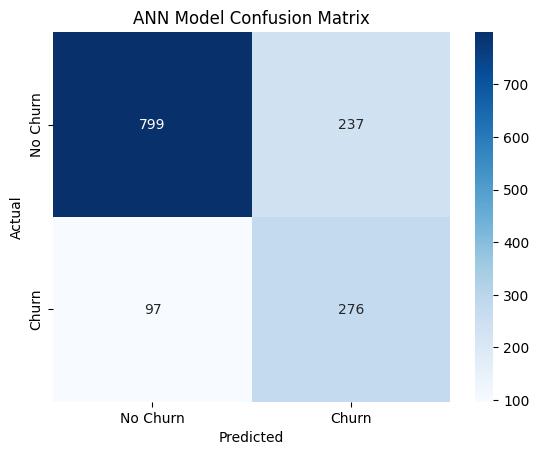

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [140]:

import seaborn as sns

def plot_conf_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix:")
    print(cm)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

    y_pred = ann.predict(X_test)
cm = plot_conf_matrix(y_test, y_pred, "ANN Model Confusion Matrix")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


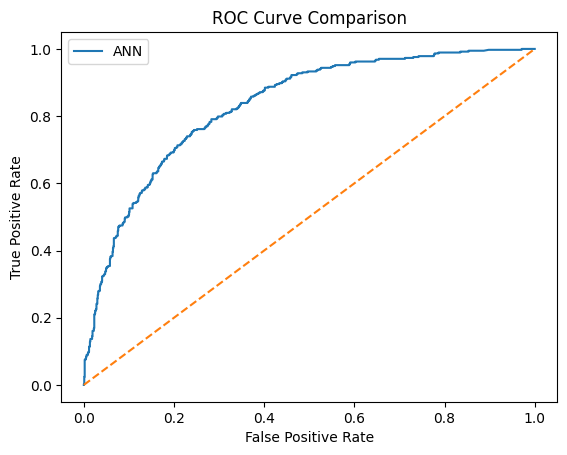

In [141]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_ann = ann.predict(X_test).ravel()



fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)


plt.plot(fpr_ann, tpr_ann, label="ANN")

plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

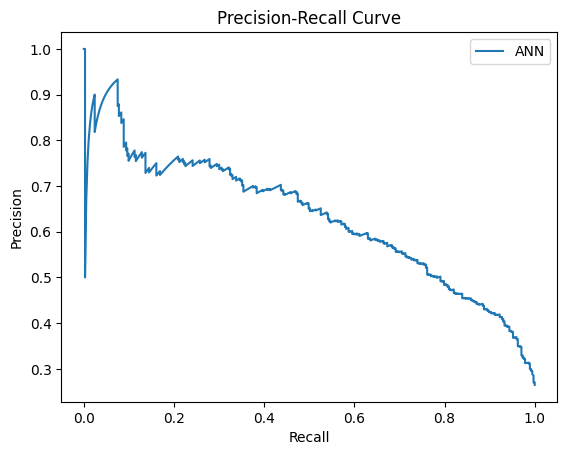

In [142]:
from sklearn.metrics import precision_recall_curve

precision_ann, recall_ann, _ = precision_recall_curve(y_test, y_prob_ann)

plt.plot(recall_ann, precision_ann, label="ANN")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()